### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 4</center>
---

### Overview

The main objective of this exercise is to study gray-level transformation functions. Such functions are mainly used for image enhancement, for example, to highlight specific image regions or to enhance the contrast. The following figure shows a subset of the most common transformation functions (<span style="color:red">figure is temporary and will be updated</span>):

<center><img src="images/transformations.png" width="900px" /></center>

---

In [15]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 4.1</span> Thresholding

One application of thresholding is segmentation (finding specific image regions for further processing). In this example, the task is to segment numbers, which can then be evaluated using optical character recognition (OCR) or other algorithms. 

Implement the following tasks:
1. Read an image (numbers.png from the folder *images*) as a grayscale image and plot it.
2. Determine the minimum gray value of the numbers (the background is black and all numbers have a gray value $> 0$).
3. Apply thresholding to the image to segment all numbers and plot the result.

*Note*: A helpful function from Numpy which can be used here is <a href="https://numpy.org/doc/stable/reference/generated/numpy.nonzero.html">`nonzero` ↗</a>. The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57">`threshold` ↗</a>.

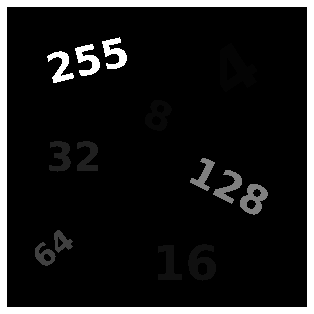

In [11]:
# write your code here
img = cv2.imread('images/numbers.png', 0)
plot_img_orig(img)

In [12]:
rows, cols = img.shape
#min_ = img[0, 0]
min_list = []
for row in range(rows):
    for col in range(cols):
        if img[row, col] > 0:
            min_ = img[row, col]
        min_list.append(min_)
print(np.min(min_list[1:])) 


NameError: name 'min_' is not defined

In [13]:
min = np.amin(img[np.nonzero(img)]) # nonzero returns the 2D indices of non-zero elements
print("min = " + str(min))

min = 4


In [4]:
np.min(img[np.nonzero(img)])

4

#### <span style="color: RoyalBlue; font-weight: bold;">Task 4.2</span> Negative Image

One application of negative images is printing on white paper. If the image structures of interest are on a dark background, mainly these structures are printed when using the negative image. In this example, an image of the Spitzer telescope is considered.

Implement the following tasks:
1. Read an image (galaxy-ic-342.jpg from the folder *images*) as a grayscale image and plot it.
2. Compute the corresponding negative image and plot the result.

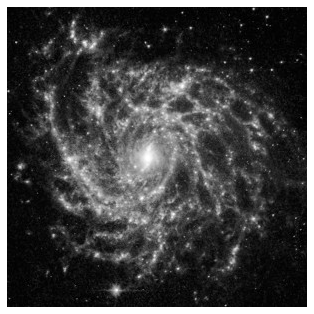

In [5]:
# write your code here
img = cv2.imread('images/galaxy-ic-342.jpg', 0)
plot_img_orig(img)


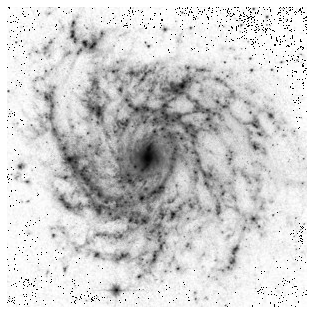

In [6]:
neg = 1-img
plot_img_orig(neg)

In [14]:
#transformation funcion involved
def compute_tf(img_in, img_out):

    img = img_in.flatten()
    neg = img_out.flatten()

    tf = img[neg]
    
    return tf

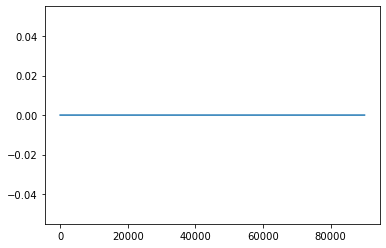

In [19]:
plt.plot(compute_tf(img, neg))

#### <span style="color: RoyalBlue; font-weight: bold;">Task 4.3</span> Gray-level Slicing

Gray-level slicing can be used to highlight specific image parts. In this example, the goal is to highlight the cells in an image while keeping the other gray values unchanged.

Implement the following tasks:
1. Write a function to apply gray-level slicing in the interval $[a, b]$.
2. Read an image (cells.png from the folder *images*) as a grayscale image and plot it.
3. Transform the image so that the cells become clearly visible and plot the result.

In [39]:
# write your code here

# map gray values from [a,b] -> [0,255]
def slice_gray_levels(img, a, b, grayval):
    rows, cols = img.shape # image size
    
    for row in range(rows):
        for col in range(cols):
            if img[row, col] > a and img[row, col] <b:
                img[row, col] = grayval
    return img
    # ...

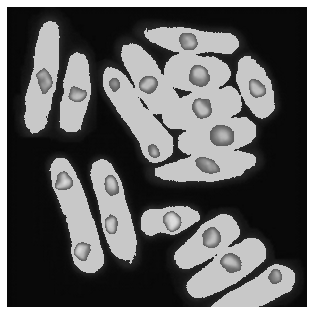

In [45]:
img = cv2.imread('images/cells.png', 0)
img.shape
slice_gray_levels(img, 40, 90, 200)
plot_img_orig(img)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 4.4</span> Range Scaling

Sometimes images have (gray) values in a specific range $[a, b]$ and should be mapped to the standard range $[0, 255]$. Some devices for image formation or certain image processing algorithms (e.g., Fourier transform) even produce values outside this range. In such cases, the goal is the following mapping (range scaling): $[a, b] \rightarrow [0, 255]$.

Implement / solve the following tasks:
1. Derive the transformation function for this mapping.
2. Write a function to map the gray values of an image according to $[a, b] \rightarrow [0, 255]$.
3. Read an image (gull.png from the folder *images*) as a grayscale image and plot it.
4. Map the gray values in this image to $[0, 255]$ and plot the result.

In [50]:
# write your code here

# map gray values from [a,b] -> [0,255]
def map_gray_values(img, a, b):
    rows, cols = img.shape # image size
    for row in range(rows):
        for col in range(cols):
            if (b-a) > 0:
                img[row, col] = 255 * ((img[row, col]-a)/(b-a))

    return img

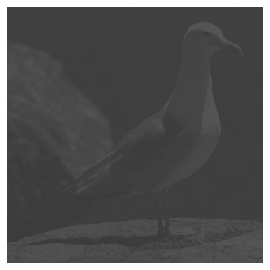

In [51]:
img = cv2.imread('images/gull.png', 0)
plot_img_orig(img)

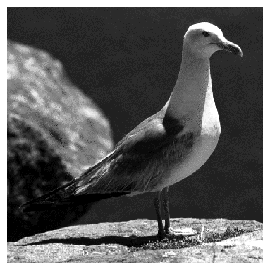

In [53]:
min = np.amin(img)
max = np.amax(img)
ranged = map_gray_values(img, min, max)
plot_img_orig(ranged)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 4.5</span> Log Transformation

The log transformation is particularly useful for contrast enhancement, as it expands the values of the dark pixels while compressing the higher level values. In this example, the magnitude of the Fourier spectrum of an image (lena.jpg) is considered. 

Implement the following tasks:
1. Write a function to apply a log transformation to an image.
2. Read an image (spectrum-gull.png from the folder *images*) as a grayscale image and plot it.
3. Transform the image and plot the result.

In [4]:
# write your code here

# apply log transformation
def log_transformation(img):
    rows, cols = img.shape # image size

    c = 255/(np.log(1+np.amax(img)))
    
    for row in range(rows):
        for col in range(cols):
            img[row, col] = c * np.log(1+img[row, col])
    
    return img

    # ...

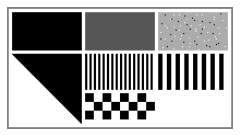

In [6]:
img = cv2.imread('images/image.png', 0)
plot_img_orig(img)

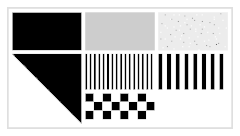

In [7]:
log_tr = log_transformation(img)
plot_img_orig(log_tr)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 4.6</span> Gamma Correction

As various devices, e.g., frame grabbers, printers and displays respond according to a power law (instead of linear to the intensity or gray values), gamma correction is often used to correct these phenomena.

Implement the following tasks:
1. Write a function to apply a gamma correction to an image.
2. Create an image with 256 $\times$ 256 pixels and an intensity ramp from left to right.
3. Transform the image to simulate how it is displayed on a monitor with $\gamma = 2$.
4. Transform the simulation image so that it is displayed correctly again.
5. Plot and compare the images.

*Note*: A helpful function from Numpy which can be used here is <a href="https://numpy.org/doc/stable/reference/generated/numpy.arange.html">`arange` ↗</a>.

In [89]:
# write your code here

# apply gamma correction
def gamma_correction(img, gamma, c=255):
    rows, cols = img.shape # image size

    for row in range(rows):
        for col in range(cols):
            img[row, col] = (1/c) * (img[row, col])**gamma
    
    return img
    
    # ...

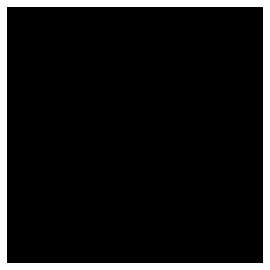

In [90]:
img = np.zeros([256, 256])
plot_img_orig(img)

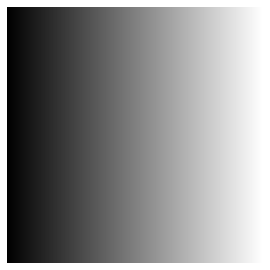

In [91]:
rows, cols = img.shape
for row in range(rows):
    for col in range(cols):
        img[row, col] = col
plot_img_orig(img)


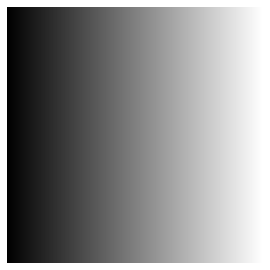

In [93]:
img = np.zeros([256, 256])
img[:, :] = np.arange(0, 256, 1)
plot_img_orig(img)

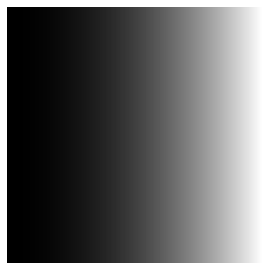

In [94]:
gamma_corr = gamma_correction(img, 2)
plot_img_orig(gamma_corr)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 4.7</span> Bit-plane slicing

Bit-plane slicing can be used to highlight the contribution of specific bits to an image. By this means, the relative importance of each bit for the appearance of an image can be analyzed. An application example is image compression, where unimportant bits can be left out.

Implement the following tasks:
1. Read an image (10-euro.png from the folder *images*) as a grayscale image and plot it.
2. Compute the bit-planes and plot the results.
3. Determine the gray value of the lettering "SPECIMEN".

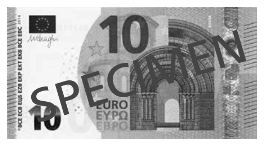

In [96]:
# write your code here
img = cv2.imread('images/10-euro.png', 0)
plot_img_orig(img)

In [98]:
image_ones = np.ones(shape=img.shape, dtype=np.uint8)
image_ones

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=uint8)

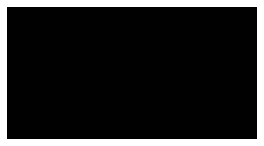

In [99]:
plot_img_orig(image_ones)

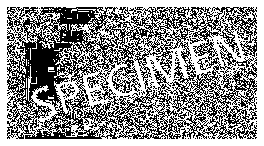

In [100]:
plane_0 = 255*cv2.bitwise_and(img >> 0, image_ones)
plot_img_orig(plane_0)

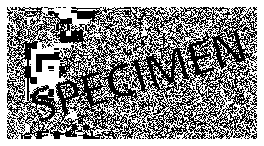

In [101]:
plane_1 = 255*cv2.bitwise_and(img >> 1, image_ones)
plot_img_orig(plane_1)

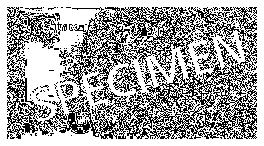

In [102]:
plane_2 = 255*cv2.bitwise_and(img >> 2, image_ones)
plot_img_orig(plane_2)

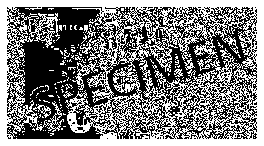

In [103]:
plane_3 = 255*cv2.bitwise_and(img >> 3, image_ones)
plot_img_orig(plane_3)

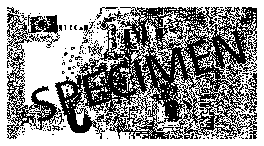

In [104]:
plane_4 = 255*cv2.bitwise_and(img >> 4, image_ones)
plot_img_orig(plane_4)

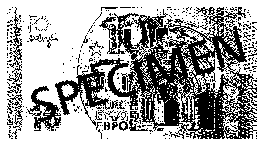

In [105]:
plane_5 = 255*cv2.bitwise_and(img >> 5, image_ones)
plot_img_orig(plane_5)

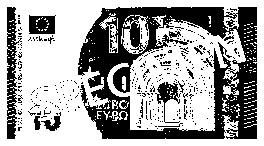

In [106]:
plane_6 = 255*cv2.bitwise_and(img >> 6, image_ones)
plot_img_orig(plane_6)

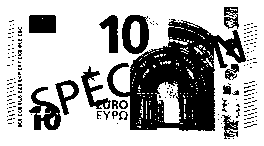

In [107]:
plane_7 = 255*cv2.bitwise_and(img >> 7, image_ones)
plot_img_orig(plane_7)

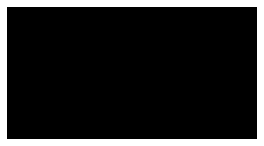

In [108]:
plane_8 = 255*cv2.bitwise_and(img >> 8, image_ones)
plot_img_orig(plane_8)

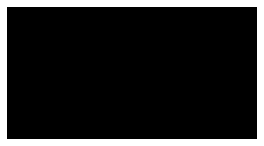

In [109]:
plane_9 = 255*cv2.bitwise_and(img >> 9, image_ones)
plot_img_orig(plane_9)